In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Shape of the dataset (rows, columns)
print("Shape:", df.shape)

# Data types and null values for each column
print("\nInfo:")
df.info()

# Total missing values per column
print("\nMissing values per column:")
print(df.isnull().sum())

# Statistical summary for numerical features
print("\nStatistical summary for numerical columns:")
print(df.describe())

# Quick look at categorical feature counts
print("\nSex value counts:")
print(df['Sex'].value_counts())

print("\nEmbarked value counts:")
print(df['Embarked'].value_counts())


Shape: (891, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Ca

In [3]:
# Label encode 'Sex'
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# One-hot encode 'Embarked'
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Drop 'Name' and 'Ticket' for now (feature engineering is advanced, focus on core ML prep)
df.drop(['Name', 'Ticket'], axis=1, inplace=True)

# Preview cleaned data
print(df.head())


   PassengerId  Survived  Pclass  Sex   Age  SibSp  Parch     Fare Cabin  \
0            1         0       3    0  22.0      1      0   7.2500   NaN   
1            2         1       1    1  38.0      1      0  71.2833   C85   
2            3         1       3    1  26.0      0      0   7.9250   NaN   
3            4         1       1    1  35.0      1      0  53.1000  C123   
4            5         0       3    0  35.0      0      0   8.0500   NaN   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  


In [4]:
from sklearn.preprocessing import StandardScaler

# Only scale columns that need it (not IDs or output)
scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

# Preview the result
df[['Age', 'Fare']].head()



,Age,Fare
0,-0.530377,-0.502445
1,0.571831,0.786845
2,-0.254825,-0.488854
3,0.365167,0.420730
4,0.365167,-0.486337


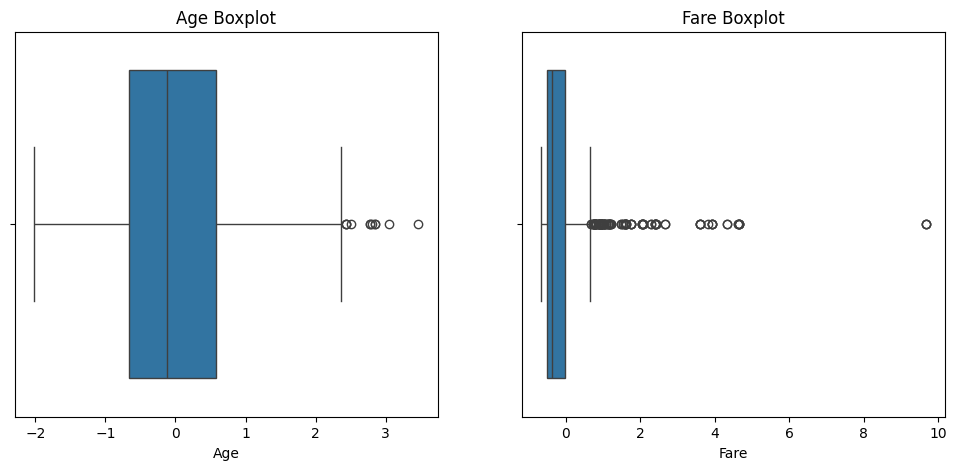

Shape after outlier removal: (694, 11)


In [5]:
# Visualize outliers with boxplots
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x=df['Age'])
plt.title('Age Boxplot')
plt.subplot(1,2,2)
sns.boxplot(x=df['Fare'])
plt.title('Fare Boxplot')
plt.show()

# Remove outliers (3 standard deviations)
for col in ['Age', 'Fare']:
    df = df[(np.abs(df[col]) <= 3)]

# Confirm result
print("Shape after outlier removal:", df.shape)



In [6]:
# Save clean dataset to CSV for re-use or sharing
df.to_csv('titanic_cleaned.csv', index=False)
print("Data exported as titanic_cleaned.csv")

# (Optional for direct ML) Train/Test split example
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Data exported as titanic_cleaned.csv
Train shape: (555, 10)
Test shape: (139, 10)
